## Odds Analysis and Prediction


## Description:
This project provides detailed historical sports betting data, including match results, team statistics, odds from multiple bookmakers, and outcomes across a range of sports and leagues. It is well-suited for machine learning applications in predictive modeling, enabling analysis of betting trends, win/loss probabilities, and strategy optimization. The dataset includes features such as team form, player performance, weather conditions, and pre-match odds. Ideal for developing classification or regression models, as well as evaluating and refining betting strategies using real-world data.

In [ ]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


## Import dataset

In [ ]:
df = pd.read_csv('sports_predictive_analysis.csv')

In [3]:
df.head()

,Match_ID,Date,Sport,Home_Team,Away_Team,Home_Team_Odds,Away_Team_Odds,Draw_Odds,Predicted_Winner,Actual_Winner
0,M00001,2024-01-24,Basketball,Gonzalezmouth Tigers,Hernandezfurt Lions,3.62,3.99,NaN,Hernandezfurt Lions,Hernandezfurt Lions
1,M00002,2025-05-03,Basketball,Rothstad Wolves,North Manuel Eagles,1.84,NaN,NaN,Rothstad Wolves,Rothstad Wolves
2,M00003,2025-04-10,Baseball,Aliciaport Lions,West Gabrielton Lions,3.93,3.29,NaN,Aliciaport Lions,Aliciaport Lions
3,M00004,2024-08-02,Tennis,Lake Samantha Eagles,Simonshire Lions,3.70,3.61,NaN,Simonshire Lions,Lake Samantha Eagles
4,M00005,2024-10-05,Tennis,Brendanport Eagles,Williamsfurt Bears,2.26,2.52,NaN,Williamsfurt Bears,Brendanport Eagles


In [4]:
df.tail()

,Match_ID,Date,Sport,Home_Team,Away_Team,Home_Team_Odds,Away_Team_Odds,Draw_Odds,Predicted_Winner,Actual_Winner
1364,M01365,2025-04-25,Tennis,Brewerstad Bears,Isaacview Bears,1.37,2.47,NaN,Brewerstad Bears,Brewerstad Bears
1365,M01366,2023-09-07,Tennis,New Raymond Lions,New Ashleeberg Lions,3.74,4.93,NaN,New Raymond Lions,New Ashleeberg Lions
1366,M01367,2025-06-18,Basketball,Lewisburgh Bears,Lake Kristinbury Tigers,2.32,2.30,NaN,Lewisburgh Bears,Lewisburgh Bears
1367,M01368,2024-02-18,Basketball,Billport Lions,West Catherinemouth Bears,4.24,2.19,NaN,West Catherinemouth Bears,West Catherinemouth Bears
1368,M01369,2024-02-01,Basketball,Andreaside Eagles,Smithborough Lions,3.66,4.23,NaN,Smithborough Lions,Smithborough Lions


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1369 entries, 0 to 1368
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Match_ID          1369 non-null   object 
 1   Date              1369 non-null   object 
 2   Sport             1369 non-null   object 
 3   Home_Team         1369 non-null   object 
 4   Away_Team         1369 non-null   object 
 5   Home_Team_Odds    1298 non-null   float64
 6   Away_Team_Odds    1282 non-null   float64
 7   Draw_Odds         498 non-null    float64
 8   Predicted_Winner  1369 non-null   object 
 9   Actual_Winner     1369 non-null   object 
dtypes: float64(3), object(7)
memory usage: 107.1+ KB


In [6]:
df.describe()

,Home_Team_Odds,Away_Team_Odds,Draw_Odds
count,1298.000000,1282.000000,498.000000
mean,3.069823,3.060031,3.103012
std,1.096600,1.087785,1.098248
min,1.200000,1.210000,1.200000
25%,2.110000,2.130000,2.142500
50%,3.080000,2.995000,3.160000
75%,3.980000,4.017500,4.062500
max,4.980000,5.000000,4.990000


In [7]:
df.isnull().sum()

Match_ID              0
Date                  0
Sport                 0
Home_Team             0
Away_Team             0
Home_Team_Odds       71
Away_Team_Odds       87
Draw_Odds           871
Predicted_Winner      0
Actual_Winner         0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df.dtypes

Match_ID             object
Date                 object
Sport                object
Home_Team            object
Away_Team            object
Home_Team_Odds      float64
Away_Team_Odds      float64
Draw_Odds           float64
Predicted_Winner     object
Actual_Winner        object
dtype: object

In [10]:
df.shape

(1369, 10)

In [11]:
df.columns

Index(['Match_ID', 'Date', 'Sport', 'Home_Team', 'Away_Team', 'Home_Team_Odds',
       'Away_Team_Odds', 'Draw_Odds', 'Predicted_Winner', 'Actual_Winner'],
      dtype='object')

## Data visualizations

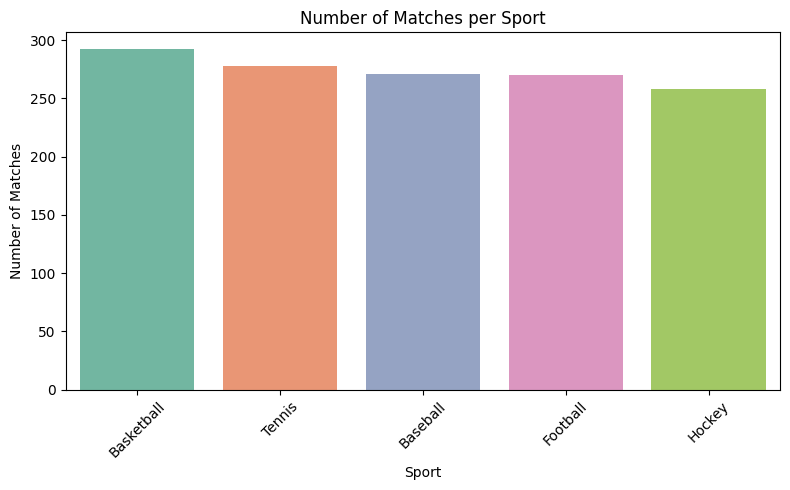

In [12]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Sport', order=df['Sport'].value_counts().index, palette='Set2')
plt.title('Number of Matches per Sport')
plt.xlabel('Sport')
plt.ylabel('Number of Matches')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [13]:
accuracy = (df['Predicted_Winner'] == df['Actual_Winner']).mean() * 100
print(f"Prediction Accuracy: {accuracy:.2f}%")


Prediction Accuracy: 43.97%


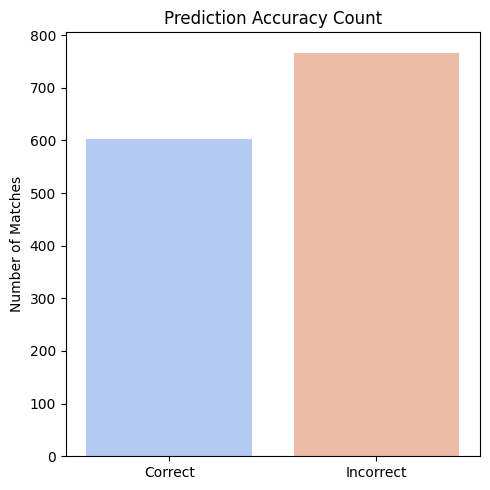

In [14]:
plt.figure(figsize=(5, 5))
sns.barplot(x=['Correct', 'Incorrect'],
            y=[(df['Predicted_Winner'] == df['Actual_Winner']).sum(),
               (df['Predicted_Winner'] != df['Actual_Winner']).sum()],
            palette='coolwarm')
plt.title('Prediction Accuracy Count')
plt.ylabel('Number of Matches')
plt.tight_layout()
plt.show()


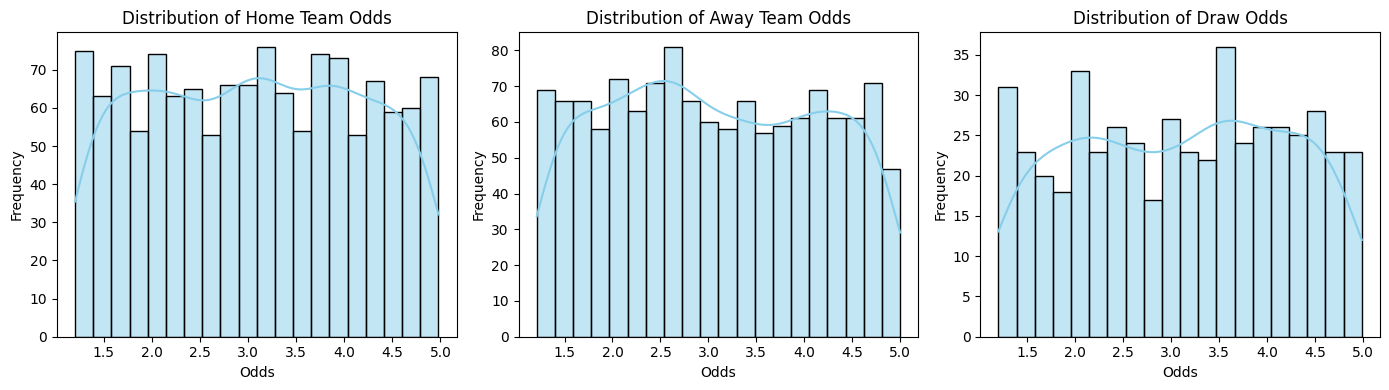

In [15]:
plt.figure(figsize=(14, 4))

for i, col in enumerate(['Home_Team_Odds', 'Away_Team_Odds', 'Draw_Odds']):
    plt.subplot(1, 3, i+1)
    sns.histplot(df[col], bins=20, kde=True, color='skyblue')
    plt.title(f'Distribution of {col.replace("_", " ")}')
    plt.xlabel('Odds')
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()


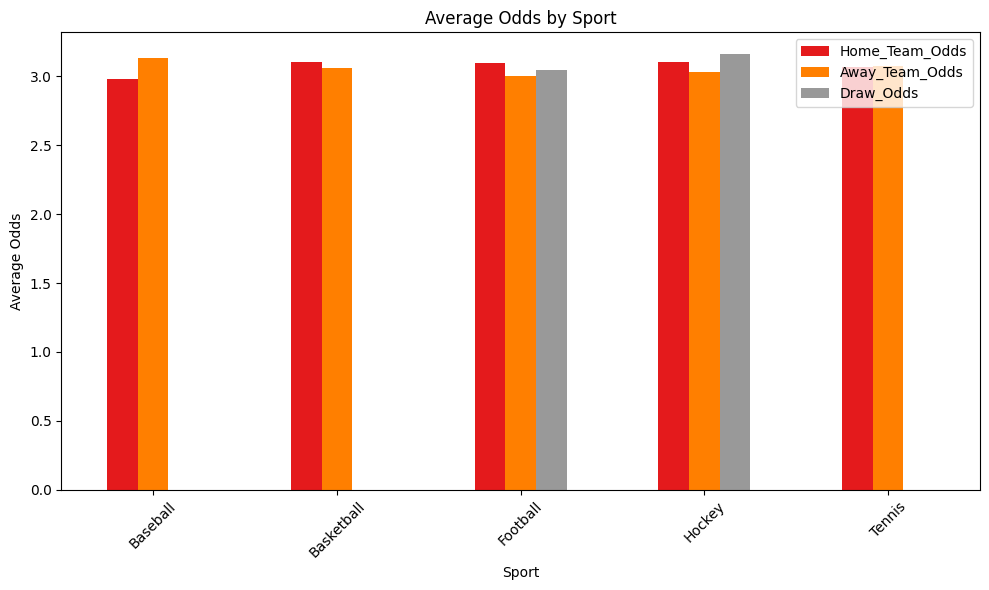

In [16]:
avg_odds = df.groupby('Sport')[['Home_Team_Odds', 'Away_Team_Odds', 'Draw_Odds']].mean().reset_index()

avg_odds.plot(x='Sport', kind='bar', figsize=(10, 6), stacked=False, colormap='Set1')
plt.title('Average Odds by Sport')
plt.xlabel('Sport')
plt.ylabel('Average Odds')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


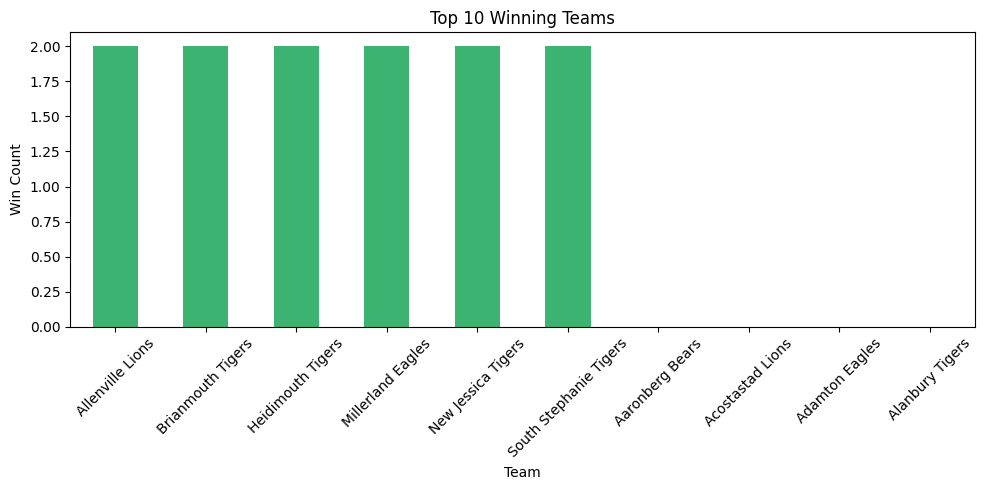

In [17]:
home_wins = df[df['Actual_Winner'] == df['Home_Team']]['Home_Team'].value_counts()
away_wins = df[df['Actual_Winner'] == df['Away_Team']]['Away_Team'].value_counts()

team_wins = (home_wins + away_wins).sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
team_wins.plot(kind='bar', color='mediumseagreen')
plt.title('Top 10 Winning Teams')
plt.ylabel('Win Count')
plt.xlabel('Team')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Predictive modeling

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

In [19]:
# Drop unnecessary columns
df = df.drop(columns=['Match_ID', 'Date', 'Predicted_Winner'])

# Label encode categorical columns
le = LabelEncoder()
for col in ['Sport', 'Home_Team', 'Away_Team', 'Actual_Winner']:
    df[col] = le.fit_transform(df[col].astype(str))

# Split features and target
X = df.drop(columns=['Actual_Winner'])
y = df['Actual_Winner']

# Impute missing values in features
imputer = SimpleImputer(strategy='mean')  # or 'median'
X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [20]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Naive Bayes": GaussianNB(),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Support Vector Machine": SVC()
}

accuracy_results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds) * 100
    accuracy_results[name] = acc

In [21]:
for model_name, acc in accuracy_results.items():
    print(f"{model_name}: {acc:.2f}%")


Logistic Regression: 8.39%
Decision Tree: 3.28%
Random Forest: 9.12%
Naive Bayes: 9.49%
K-Nearest Neighbors: 4.01%
Support Vector Machine: 9.49%


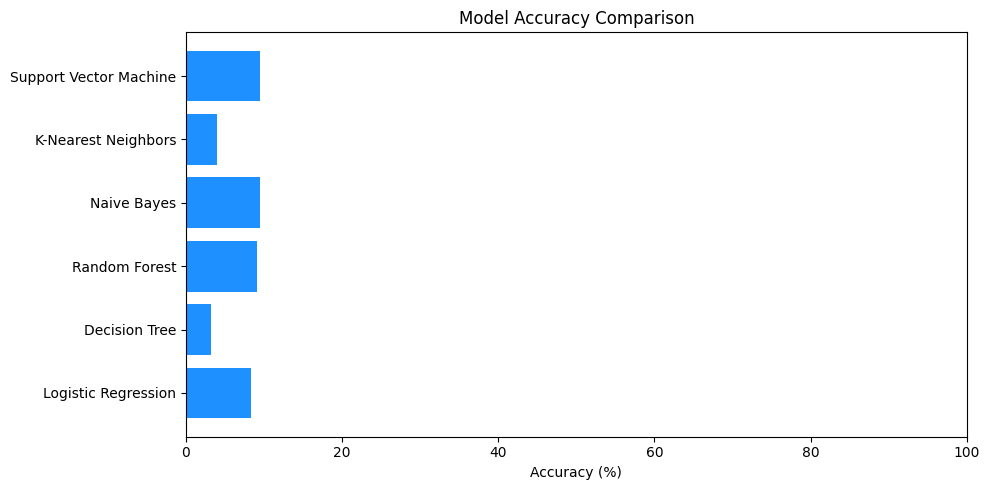

In [22]:


plt.figure(figsize=(10, 5))
plt.barh(list(accuracy_results.keys()), list(accuracy_results.values()), color='dodgerblue')
plt.xlabel("Accuracy (%)")
plt.title("Model Accuracy Comparison")
plt.xlim(0, 100)
plt.tight_layout()
plt.show()
